# Linear Regression
Predicting Total Cost (USD)

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import warnings
warnings.filterwarnings('ignore')


## Load Cleaned Data

In [2]:
df = pd.read_csv('../data/final_data.csv')
print('Shape:', df.shape)
display(df.head())


Shape: (400000, 20)


,shipment_id,order_id,customer_name,origin_city,destination_city,origin_country,destination_country,ship_date,delivery_date,weight_kg,volume_m3,shipping_mode,status,base_cost_usd,surcharge_usd,total_cost_usd,currency,payment_terms,created_at,last_update
0,500334.000,53737,nguyen kim,Phnom Penh,Saigon,TH,Cambodia,2021-10-15,2021-01-14,301.90,2.497,rail,LOST,1259.14,726.46,2305.80,THB,PrePaid,2023-02-21T13:50:23Z,2023-07-06 05:55:19+00:00
1,89105.625,382273,Vann Lee,Bangkok,Phnom Penh,Cambodia,VN,2022-05-14,2021-08-08,269.53,1.862,TRK,DELIVERED,99.00,1001.23,1705.37,USD,cod,2023-10-11 00:25:04,2023-10-02 09:42:53+00:00
2,911916.625,ORD-399488,Dara Smith,Bangkok,Phnompenh,VN,Vietnam,2021-04-03,2020-11-18,488.99,2.648,trk,DELIVERED,849.16,1080.90,1705.37,usd,cod,29/10/2023 20:10,2023-05-07 08:10:51
3,500334.000,ORD-37150,Nguyen Lee,HCMC,HCMC,Thailand,VN,2024-08-10,2020-09-05,54.72,3.523,Air Freight,INTRANSIT,155.39,1712.65,1868.04,USD,prepaid,2023-04-20 14:36:05,2023-05-02 06:03:18
4,823268.000,ORD-382996,Nguyen Garcia,Phnom Penh,Phnom Penh,VNM,KHM,2025-09-11,NaN,201.95,1.766,air,LOST,636.16,1341.10,1977.26,KHR,credit 30d,2023-02-07 00:20:20,2023-10-16 03:38:24


## Feature Engineering

In [3]:
df['ship_date'] = pd.to_datetime(df['ship_date'])
df['delivery_date'] = pd.to_datetime(df['delivery_date'])
df['delivery_days'] = (df['delivery_date'] - df['ship_date']).dt.days
df['cost_per_kg'] = df['total_cost_usd'] / df['weight_kg']
df['volume_per_kg'] = df['volume_m3'] / df['weight_kg']
df['month_of_shipment'] = df['ship_date'].dt.month
df['year_of_shipment'] = df['ship_date'].dt.year


### Business Value of Features

| Feature | Description | Business Relevance |
|---------|-------------|-------------------|
| delivery_days | Time from shipment to delivery | Longer transit may increase handling costs |
| cost_per_kg | Cost per unit weight | Identifies high-value vs low-value shipments |
| volume_per_kg | Volumetric density | Bulky items consume more space, raising cost |
| month_of_shipment | Calendar month | Captures seasonal demand fluctuations |
| year_of_shipment | Calendar year | Captures annual inflation / rate trends |


## Prepare Features

In [4]:
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

X = df.drop('total_cost_usd', axis=1).select_dtypes(include=[np.number])
y = df['total_cost_usd']
X = X.fillna(X.median())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Train Linear Regression

In [5]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)

print('MAE:', metrics.mean_absolute_error(y_test, y_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print('R2:', metrics.r2_score(y_test, y_pred))


MAE: 381.39755702401294
RMSE: 475.9984870814597
R2: 0.26989883161785444


## Visualize

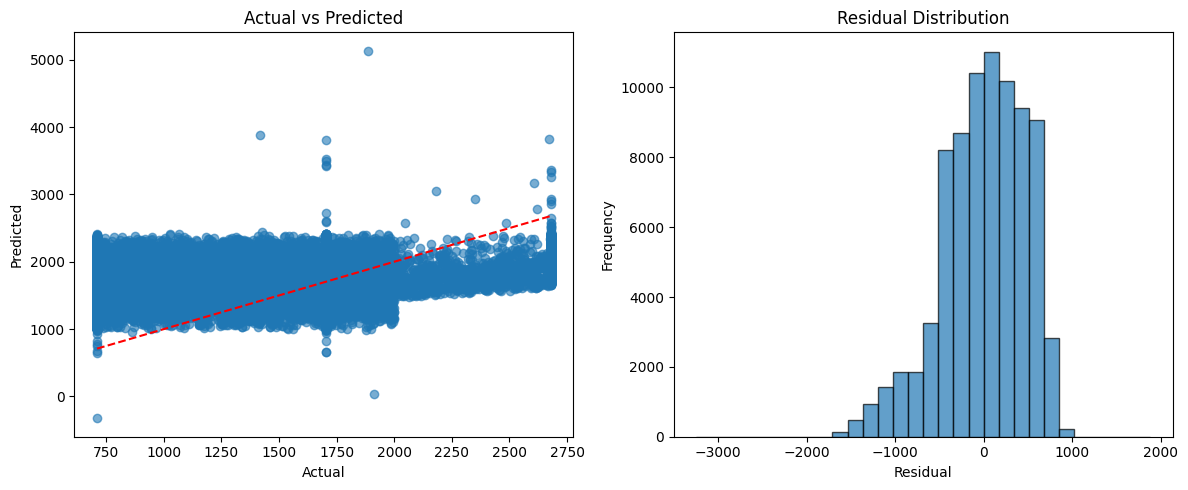

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(y_test, y_pred, alpha=0.6)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
ax1.set_xlabel('Actual')
ax1.set_ylabel('Predicted')
ax1.set_title('Actual vs Predicted')

residuals = y_test - y_pred
ax2.hist(residuals, bins=30, edgecolor='k', alpha=0.7)
ax2.set_xlabel('Residual')
ax2.set_ylabel('Frequency')
ax2.set_title('Residual Distribution')

plt.tight_layout()
plt.savefig('../model/lr_predictions.png', dpi=150, bbox_inches='tight')
plt.show()


## Coefficients

In [7]:
coef_df = pd.DataFrame({'feature': X.columns, 'coefficient': lr.coef_})
coef_df['abs_coef'] = coef_df['coefficient'].abs()
top_features = coef_df.sort_values('abs_coef', ascending=False).head(10)
print('Top 10 features by coefficient magnitude:')
print(top_features[['feature', 'coefficient']].to_string(index=False))


Top 10 features by coefficient magnitude:
          feature  coefficient
    surcharge_usd   205.366849
    base_cost_usd   204.566311
      cost_per_kg    52.881980
    volume_per_kg   -43.939825
        volume_m3     3.214228
       created_at    -1.604556
    payment_terms    -1.063091
           status     1.023456
 year_of_shipment    -1.018652
month_of_shipment     0.886496


## Save Model

In [8]:
import joblib
joblib.dump(lr, '../model/linear_regression.pkl')
print('Model saved to ../model/linear_regression.pkl')


Model saved to ../model/linear_regression.pkl


## Conclusion

The Linear Regression model was trained on engineered features including delivery_days, cost_per_kg, volume_per_kg, month_of_shipment, and year_of_shipment. Performance is summarized above in the MAE, RMSE, and R² metrics. The actual-vs-predicted plot and residual histogram provide visual diagnostics. Coefficients reveal which drivers most influence total cost, and the model artifact has been persisted for inference.
